# Project 2: Optimization

In [1]:
# FIXME: Enter your group name here
GROUP = "Monday_12"
# List of group members
# uaaaaa
# ubbbbb
# uccccc

## 2.0 Preparation

Ensure that you run this notebook in your project environment from the previous project.

Import necessary Python modules. We will re-use the FeniCS interface from the previous project. For that to work, you need to place this Jupyter notebook in the `project` directory (the directory containing `phys.ipynb`).

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import ax
import import_ipynb

from phys import FenicsInterface
from fem.base import grids

<string>:18: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


dolfinx 0.10.0


## 2.1 Create the blackbox-function 

Complete the function `solve_fem` below, which we will use for our optimization problem. The given signature and docstring of the function defines the inputs and outputs. Do not change the signature or docstring.

**(a) Implement the steps needed to solve the load-controlled elastoplastic cube.**

Use the `main.py` from the previous project as starting point (You can copy & paste most of it and modify only the necessary parts).

Apply Dirichlet (displacement) boundary conditions `bc_u`. Choose a bending deformation on the `"xn"` and `"xp"` boundaries. This results in a load-controlled bending problem.

*Tip: disable plotting in the FenicsInterface `fi.plot = False` to accelerate computations.* 

**(b) Assemble the results dictionary.**

Assemble all frames in the `fe_histories` into numerical tensors (`np.asarray`) for each element. 

Use the `numpy` python module (`np.stack`, `np.reshape`). 

The final tensors should have the shape (T X Y F) with T: number of time frames, X and Y: grid dimensionality, F: number of components/features.

**(c) Compute additional features and metrics.**

Use the functions `np.min` and `np.max` and check out slicing in numpy.
add the metrics to the result dictionary

In [3]:
# Do not change this cell!
#   This function is a useful helper to apply grid encoding to the frame data. The lines
#   using it later are already prepared for you. You do not need to use it anywhere else
#   in the notebook or modify this function.
def apply_grid_encoding(frame, grid_shape):
    """Grid encode the frame data."""
    Xi = frame["Xi"]
    origin = np.min(Xi, axis=0)
    geometry = tuple(np.max(Xi, axis=0) - np.min(Xi, axis=0))
    grid_coords = grids.generate_grid(geometry, grid_shape) + origin
    reduced_frame = {
        k: v
        for k, v in frame.items()
        if "fenics" not in k and "bc_" not in k and isinstance(v, np.ndarray)
    }
    del reduced_frame["Pi"]
    _, _, grid_encoded = grids.grid_encode(grid_coords, grid_shape, Xi, reduced_frame)
    return grid_encoded

In [4]:
def solve_fem(E=7e10, u0=1e-3, nu=0.3, rho=0.0, sig0=2.50e8, Et=1e-9):
    """Solve the elastoplastic cube problem using the FenicsInterface.

    Args:
        E (float, optional): Young's (elastic) modulus. Defaults to 7e10.
        u0 (float, optional): Maximum displacement at the left and right edges of the cube. Defaults to 1e-3.
        nu (float, optional): Poisson's ratio. Defaults to 0.3.
        rho (float, optional): Density of the material. Defaults to 0.0.
        sig0 (float, optional): Initial yield stress. Defaults to 2.50e8.
        Et (float, optional): Tangent modulus for kinematic hardening. Defaults to 1e-9.

    Returns:
        dict: A dictionary containing the results of the simulation as feature tensors.
    """

    # FIXME Create a FenicsInterface object
    #   This is the main interface to the Fenics library
    #   It handles the setup of the problem, the mesh generation,
    #   the assembly of the system matrices and vectors,
    #   and the solution of the system

    

    fi = FenicsInterface()
    fi.VERBOSITY = 2
    fi.DEBUG = False
    #fi.plot = False



    # Define geometry, material properties, and boundary conditions
    #   Keep the geometry as a 2D square with length 1.0 in both x and y directions
    geometry = [1.0, 1.0]  # Length in x and y directions

    # Define material properties
    #    Bilinear elastoplastic material with kinematic hardening
    material = [E, nu, rho, sig0, Et]

    # Define properties
    #    Thickness of the material is 1.0, which is a common assumption for 2D problems
    thickness = 1.0  # Thickness of the material
    properties = [thickness]

    # FIXME Define boundary conditions
    #    At the left and right edges of the cube, we apply linear bending displacement.
    #    The dislacement are defined as a function of the y coordinate.
    #    The maximum displacement is defined as u0 as an input to the function.
    

    def lin_pos_y(node, max_val, **kwargs):
        return max_val * 2.0 * (node[2] - geometry[1] / 2.0) / geometry[1]

    lin_pos_y.cpp_code = "max_val * (x[1] - geometry1 / 2.0) * (2.0 / geometry1)"

    def lin_neg_y(node, max_val, **kwargs):
        return -lin_pos_y(node, max_val)

    lin_neg_y.cpp_code = "- max_val * (x[1] - geometry1 / 2.0) * (2.0 / geometry1)"
    
    bc_u1 = {
        "xn": [lin_pos_y, None],  # left edge
        "xp": [lin_neg_y, None],  # right edge
        "yn": [],
        "yp": [],
        "all": [],
        "pointwise": [],
    }
    fi.bc_fun_kwargs = {"max_val": u0, "unit_disp": 0.0, "coords": None}



    # Finite element settings
    grid_shape = [27, 27]  # Number of elements in x and y directions
    fi.interpolation_order = 2  # element interpolation order (1: linear, 2: quadratic)
    fi.min_increment = 5  # Minimum number of time increments
    fi.max_iteration = 100  # Maximum number of iterations
    fi.tol = 1e-10  # Tolerance for convergence
    fi.regularization = 1.0  # Regularization parameter

    fe_histories = []  # List to store the finite element histories

    # FIXME Load the geometry
    print("Loading geometry...")
    
    
    
    fe_history_load = fi.adaptive_time_increments(
        fi.elastoplastic_cube, geometry, material, properties, grid_shape, bc_u1
    )
    
    
    
    fe_histories += [fe_history_load]

    # Check if the results are numerically stable and correct
    assert (
        np.max(fi.extract_stress_values(fe_histories[0][-1]["Si"], stress_type="mises"))
        > 0.0
    )
    assert np.max(
        fi.extract_stress_values(fe_histories[0][-1]["Si"], stress_type="mises")
    ) <= sig0 * (1.0 + 1e-4)

    # FIXME Assemble the results into a dictionary containing the feature tensors
    #    The tensors should be of the following dimensions:
    #    T: Number of time frames (varies with the number of increments)
    #    X: Number of grid points in x direction (27 in this case)
    #    Y: Number of grid points in y direction (27 in this case)
    #    F: Number of features (2 for displacement and force, 6 for stress,
    #       1 for Von Mises stress)
    frames = [
        apply_grid_encoding(f, grid_shape)
        for h in fe_histories
        for f in h.values()
        if f
    ]
    frames = [
        {k: np.zeros_like(v) for k, v in frames[-1].items()}
    ] + frames  # add initial zero frame for initial state
    
    
    U = np.stack([f["Ui"] for f in frames], axis=0)
    F = np.stack([f["Fi"] for f in frames], axis=0)
    S = np.stack([f["Si"] for f in frames], axis=0)
    Mises = fi.extract_stress_values(S, stress_type="mises")
    
    
    Mises = Mises[..., np.newaxis]  # Add a new axis for compatibility
    
    results = {
        "U": U,  # Displacement tensor of shape (T, X, Y, 2)
        "F": F,  # Force tensor of shape (T, X, Y, 2)
        "S": S,  # Stress tensor of shape (T, X, Y, 6)
        "Mises": Mises,  # Von Mises stress tensor of shape (T, X, Y, 1)
    }

    # FIXME Compute non-local and non-directional features from the results.
    #  Compute the magnitudes of the displacement and force vectors at each grid point
    #  for each time frame and store them in the results dictionary.
    
    
    
    u = np.linalg.norm(U, axis=-1)  # Magnitude of displacement tensor of shape (T, X, Y, 1)
    f = np.linalg.norm(F, axis=-1)  # Magnitude of force tensor of shape (T, X, Y, 1)
    results["max_u"] = np.max(u, axis=(1, 2), keepdims=False)  # Max displacement magnitude tensor of shape (T, 1)
    results["min_u"] = np.min(u, axis=(1, 2), keepdims=False)  # Min displacement magnitude tensor of shape (T, 1)
    results["max_f"] = np.max(f, axis=(1, 2), keepdims=False)  # Max force magnitude tensor of shape (T, 1)
    results["min_f"] = np.min(f, axis=(1, 2), keepdims=False)  # Min force magnitude tensor of shape (T, 1)
    results["max_mises"] = np.max(Mises, axis=(1, 2), keepdims=False)  # Max Von Mises stress tensor of shape (T, 1)
    results["min_mises"] = np.min(Mises, axis=(1, 2), keepdims=False)  # Min Von Mises stress tensor of shape (T, 1)
    

    # FIXME Compute metrics for the objective function
    #   The objective function is the maximum Von Mises stress over all time frames
    #   and the maximum displacement at the last time frame. Store the metrics in the
    #   results dictionary as scalars.
    
    
    
    results["objective_max_equivalent_stress"] = np.max(
            Mises
        )
    results["objective_final_displacement"] = np.max(
            u[-1]
        )
    
    
    
    return results

**(d) Try your implemented function.**

In [5]:
results = solve_fem(E=7e10, u0=3e-3)

Loading geometry...


Interface increments: elastoplastic_cube:   0%|          | [00:00<?, ?inc/s, control=-1, delta=-1, in…

Fenicsx Newton-Raphson:   0%|          | [00:00<?, ?iter/s, (rel) displacement=-1, (rel) energy=-1, (rel)…

Fenicsx Newton-Raphson:   0%|          | [00:00<?, ?iter/s, (rel) displacement=-1, (rel) energy=-1, (rel)…

Fenicsx Newton-Raphson:   0%|          | [00:00<?, ?iter/s, (rel) displacement=-1, (rel) energy=-1, (rel)…

Fenicsx Newton-Raphson:   0%|          | [00:00<?, ?iter/s, (rel) displacement=-1, (rel) energy=-1, (rel)…

Fenicsx Newton-Raphson:   0%|          | [00:00<?, ?iter/s, (rel) displacement=-1, (rel) energy=-1, (rel)…

In [6]:
for key, value in results.items():
    print(f"{key}: {value.shape if isinstance(value, np.ndarray) else value}")

U: (6, 27, 27, 2)
F: (6, 27, 27, 2)
S: (6, 27, 27, 6)
Mises: (6, 27, 27, 1)
max_u: (6,)
min_u: (6,)
max_f: (6,)
min_f: (6,)
max_mises: (6, 1)
min_mises: (6, 1)
objective_max_equivalent_stress: 250000000.00000015
objective_final_displacement: 0.0033386367907852666


**(e) Plot the results**

Use matplotlib to plot the von-Mises stress over the grid points for the last frame. Use `plt.imshow`.

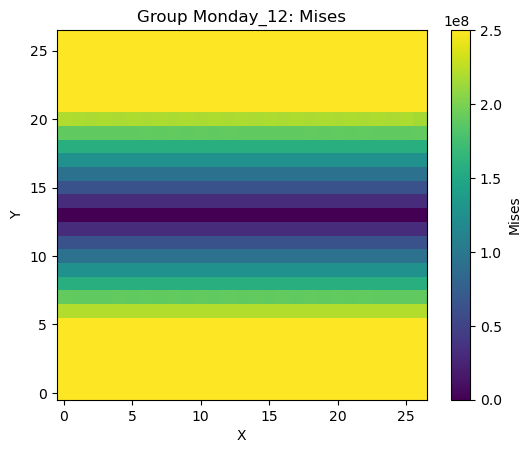

In [7]:
# FIXME Plot features over the grid
feature = "Mises"
vmin = np.min(results[feature])
vmax = np.max(results[feature])
plt.title(f"Group {GROUP}: {feature}")
plt.xlabel("X")
plt.ylabel("Y")

plt.imshow(
    results[feature][-1].squeeze().T,
    origin="lower",
    vmin=vmin,
    vmax=vmax,
    cmap="viridis"
)

plt.colorbar(label=feature)
plt.show()

Plot the load-displacement curve (`max_f` over `max_u`) using `plt.plot`. 

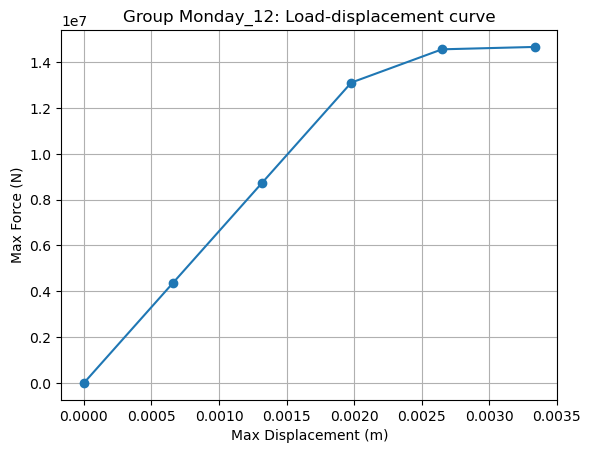

In [8]:
# FIXME Plot the load-displacement curve
x = results["max_u"].squeeze()   # max displacement
y = results["max_f"].squeeze()   # max force

plt.title(f"Group {GROUP}: Load-displacement curve")

plt.plot(x, y, "o-")

plt.xlabel("Max Displacement (m)")
plt.ylabel("Max Force (N)")

plt.grid(True)
plt.show()

# 2.2 Solve an optimization problem using Ax

We will now use acive learning with Bayesian Optimization to investigate the physics-based model of the elastoplastic finite element code.

The function `solve_fem` that you implemented before will serve as blackbox function.

We will use the ax platform for this. Check out the tutorials and documetation on https://ax.dev/.
In particular, the Quickstart and Multi-Objective Optimization with Ax tutorials will be helpful.

**(a) Set up the experiment**

Vary the parameter `"E"` between $5e10$ and $9e10$ and the parameter `"u0"` between $1e-3$ and $5e-3$. Keep all other parameters in your blackbox functions at their default values. 

Implement a multi-objective optimization to maximize `"objective_max_equivalent_stress"` and minimize `"objective_final_displacement"`.

In [9]:
from ax.api.client import Client
from ax.api.configs import RangeParameterConfig
client = ax.Client()

# FIXME Configure the experiment
client.configure_experiment(
    name="fem_elastoplastic_bo",
    parameters=[
        RangeParameterConfig(
            name = "E",
            bounds = [5e10, 9e10],
            parameter_type = "float",
        ),
        RangeParameterConfig(
            name = "u0",
            bounds = [1e-3, 5e-3],
            parameter_type = "float",
        ),
    ],
)

# FIXME Configure the objective function
client.configure_optimization(objective = "objective_max_equivalent_stress, -objective_final_displacement")

**(b) Run 20 trials of optimization**

Use the function `solve_fem` that you implemented before as blackbox function.

In [10]:
for _ in range(20):
    # FIXME get the next trial, solve the FEM problem, extract the metrics, and 
    #   complete the trial
    
    
    trial_index, parameters = client.get_next_trials(max_trials=1).popitem()
    
    print(f"Trial {trial_index}:")
    print(f"  Parameters: {parameters}")

    results = solve_fem(
        E=parameters["E"],
        u0=parameters["u0"],
    )

    #extract metrics
    metrics = {
        "objective_max_equivalent_stress": results["objective_max_equivalent_stress"],
        "objective_final_displacement": results["objective_final_displacement"],
    }

    print(f"  Metrics: {metrics}")

    #complete the trial
    client.complete_trial(
        trial_index=trial_index,
        raw_data=metrics,
    )   

[INFO 07-05 16:34:32] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol', use_existing_trials_for_initialization=True), GenerationNode(name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, generator_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')], suggested_experiment_status=ExperimentStatus.INITIALIZATION, pausing_criteria=[MaxTrialsAwaitingData(threshold=5)]), GenerationNode(name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, generator_key_override=None)], transition_criteria=None, suggested_experiment_status=ExperimentStatus.OPTIMIZATION, pausing_criteria=None)]) chosen based on user input and problem structure.
[INFO 07-05 16:34:32] ax.api.client: Generated new trial 0 with parameters {'E': 70000000000.0, 'u0': 0.003} using GenerationNode CenterOfSearchSpace.


Trial 0:
  Parameters: {'E': 70000000000.0, 'u0': 0.003}
Loading geometry...


Interface increments: elastoplastic_cube:   0%|          | [00:00<?, ?inc/s, control=-1, delta=-1, in…

Fenicsx Newton-Raphson:   0%|          | [00:00<?, ?iter/s, (rel) displacement=-1, (rel) energy=-1, (rel)…

Fenicsx Newton-Raphson:   0%|          | [00:00<?, ?iter/s, (rel) displacement=-1, (rel) energy=-1, (rel)…

...

Fenicsx Newton-Raphson:   0%|          | [00:00<?, ?iter/s, (rel) displacement=-1, (rel) energy=-1, (rel)…

Fenicsx Newton-Raphson:   0%|          | [00:00<?, ?iter/s, (rel) displacement=-1, (rel) energy=-1, (rel)…

Fenicsx Newton-Raphson:   0%|          | [00:00<?, ?iter/s, (rel) displacement=-1, (rel) energy=-1, (rel)…

  Metrics: {'objective_max_equivalent_stress': np.float64(183667676.6356383), 'objective_final_displacement': np.float64(0.0011512419413482514)}


[INFO 07-05 16:35:18] ax.api.client: Trial 19 marked COMPLETED.


**(c) Plot the analysis**

Observe the trade-off between the objectives and the influence of the parameters on the individual objectives in the contour plots (*Great to describe in your report!*).

,trial_index,arm_name,trial_status,generation_node,objective_max_equivalent_stress,objective_final_displacement,E,u0
0,0,0_0,COMPLETED,CenterOfSearchSpace,2.500000e+08,0.003339,7.000000e+10,0.003000
1,1,1_0,COMPLETED,Sobol,2.500000e+08,0.003656,6.564127e+10,0.003282
2,2,2_0,COMPLETED,Sobol,1.923637e+08,0.001449,7.472418e+10,0.001318
3,3,3_0,COMPLETED,Sobol,2.500000e+08,0.005396,8.721963e+10,0.004731
4,4,4_0,COMPLETED,Sobol,2.500000e+08,0.002898,5.313603e+10,0.002634
5,5,5_0,COMPLETED,MBM,1.757377e+08,0.001100,8.996275e+10,0.001000
6,6,6_0,COMPLETED,MBM,1.899345e+08,0.002090,5.116967e+10,0.001900
7,7,7_0,COMPLETED,MBM,1.013576e+08,0.001100,5.188646e+10,0.001000
8,8,8_0,COMPLETED,MBM,2.500000e+08,0.002174,7.347617e+10,0.001974
9,9,9_0,COMPLETED,MBM,2.500000e+08,0.001738,8.271291e+10,0.001580


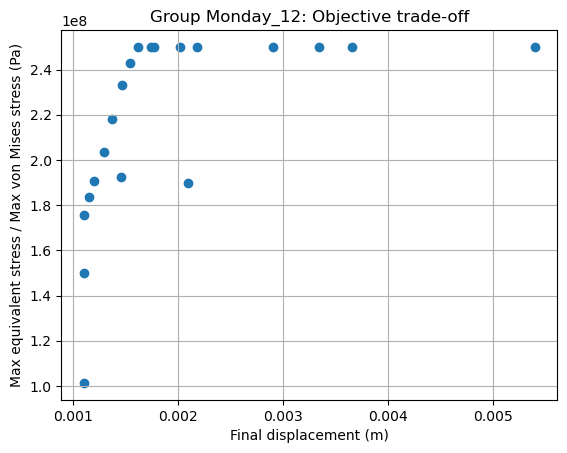

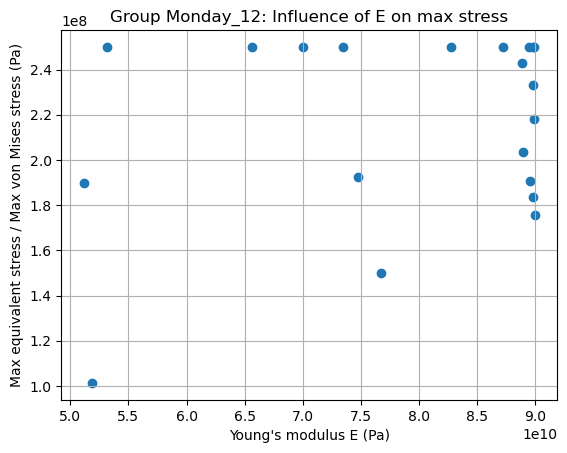

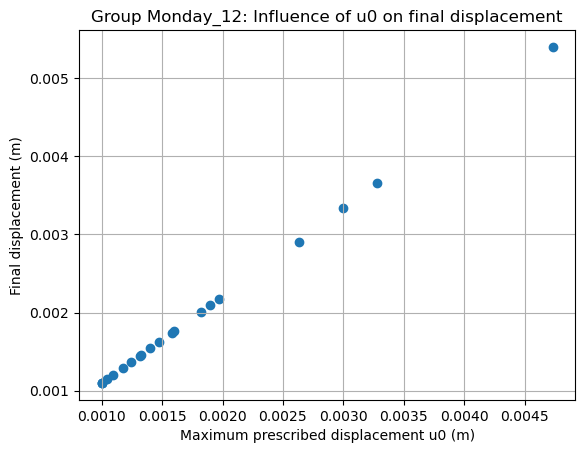

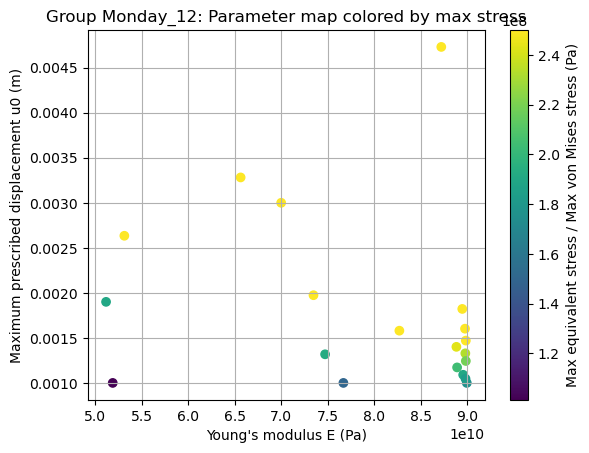

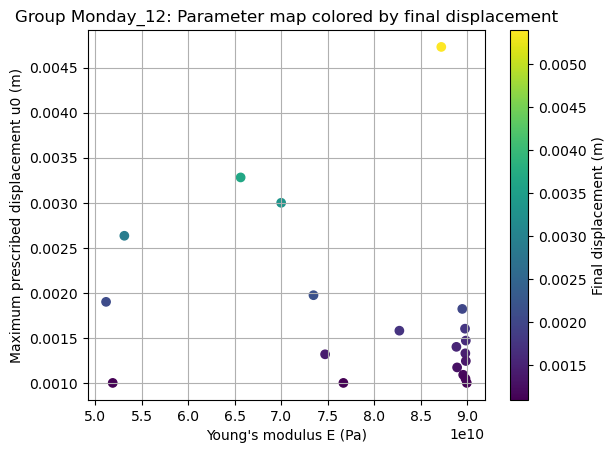

In [13]:
# FIXME Compute the analysis plots (check the Ax documentation for details)
df = client.summarize()
display(df)

# Make sure values are numeric
df["E"] = df["E"].astype(float)
df["u0"] = df["u0"].astype(float)
df["objective_max_equivalent_stress"] = df["objective_max_equivalent_stress"].astype(float)
df["objective_final_displacement"] = df["objective_final_displacement"].astype(float)


# 1) Objective trade-off: stress vs displacement
plt.figure()
plt.scatter(
    df["objective_final_displacement"],
    df["objective_max_equivalent_stress"]
)
plt.xlabel("Final displacement (m)")
plt.ylabel("Max equivalent stress / Max von Mises stress (Pa)")
plt.title(f"Group {GROUP}: Objective trade-off")
plt.grid(True)
plt.show()


# 2) Influence of E on max equivalent stress
plt.figure()
plt.scatter(
    df["E"],
    df["objective_max_equivalent_stress"]
)
plt.xlabel("Young's modulus E (Pa)")
plt.ylabel("Max equivalent stress / Max von Mises stress (Pa)")
plt.title(f"Group {GROUP}: Influence of E on max stress")
plt.grid(True)
plt.show()


# 3) Influence of u0 on final displacement
plt.figure()
plt.scatter(
    df["u0"],
    df["objective_final_displacement"]
)
plt.xlabel("Maximum prescribed displacement u0 (m)")
plt.ylabel("Final displacement (m)")
plt.title(f"Group {GROUP}: Influence of u0 on final displacement")
plt.grid(True)
plt.show()


# 4) Parameter map colored by max equivalent stress
plt.figure()
sc = plt.scatter(
    df["E"],
    df["u0"],
    c=df["objective_max_equivalent_stress"]
)
plt.xlabel("Young's modulus E (Pa)")
plt.ylabel("Maximum prescribed displacement u0 (m)")
plt.title(f"Group {GROUP}: Parameter map colored by max stress")
plt.colorbar(sc, label="Max equivalent stress / Max von Mises stress (Pa)")
plt.grid(True)
plt.show()


# 5) Parameter map colored by final displacement
plt.figure()
sc = plt.scatter(
    df["E"],
    df["u0"],
    c=df["objective_final_displacement"]
)
plt.xlabel("Young's modulus E (Pa)")
plt.ylabel("Maximum prescribed displacement u0 (m)")
plt.title(f"Group {GROUP}: Parameter map colored by final displacement")
plt.colorbar(sc, label="Final displacement (m)")
plt.grid(True)
plt.show()